In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits.mplot3d import Axes3D
print("Libraries Imported")


Libraries Imported


In [16]:
#(2) Defining datasets - 

data = {
	    "StudyHours":[1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,
	     6.0,6.5,7.0,7.5,8.0,8.5,9.0,9.5,10.0,10.5,
	     11.0,2.2,3.8,4.2,5.7,6.8,7.3,8.6,9.1,10.2,
	     1.8,2.7,3.3,4.7,5.2,6.3,7.8,8.3,9.7,10.8],

	    "SocialMedia":[5.0,4.8,4.5,4.2,4.0,3.8,3.5,3.2,3.0,2.8,
	     2.5,2.3,2.0,1.8,1.5,1.3,1.0,0.8,0.6,0.5,
	     0.3,4.4,3.7,3.4,2.7,2.2,1.9,1.2,0.9,0.7,
	     4.6,4.1,3.9,3.1,2.9,2.4,1.6,1.4,0.7,0.4],

	    "Score":[30,33,36,40,44,48,52,55,59,62,
	     66,69,73,76,80,83,86,89,92,94,
	     96,38,50,54,64,71,75,84,87,93,
	     34,42,46,57,60,67,78,82,90,95]
	}


In [17]:
#(2) Defining datasets - 

data = {
	    "StudyHours":[1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,
	     6.0,6.5,7.0,7.5,8.0,8.5,9.0,9.5,10.0,10.5,
	     11.0,2.2,3.8,4.2,5.7,6.8,7.3,8.6,9.1,10.2,
	     1.8,2.7,3.3,4.7,5.2,6.3,7.8,8.3,9.7,10.8],

	    "SocialMedia":[5.0,4.8,4.5,4.2,4.0,3.8,3.5,3.2,3.0,2.8,
	     2.5,2.3,2.0,1.8,1.5,1.3,1.0,0.8,0.6,0.5,
	     0.3,4.4,3.7,3.4,2.7,2.2,1.9,1.2,0.9,0.7,
	     4.6,4.1,3.9,3.1,2.9,2.4,1.6,1.4,0.7,0.4],

	    "Score":[30,33,36,40,44,48,52,55,59,62,
	     66,69,73,76,80,83,86,89,92,94,
	     96,38,50,54,64,71,75,84,87,93,
	     34,42,46,57,60,67,78,82,90,95]
	}

data loading

In [18]:
df = pd.DataFrame(data)
print(df.tail(10))

    StudyHours  SocialMedia  Score
30         1.8          4.6     34
31         2.7          4.1     42
32         3.3          3.9     46
33         4.7          3.1     57
34         5.2          2.9     60
35         6.3          2.4     67
36         7.8          1.6     78
37         8.3          1.4     82
38         9.7          0.7     90
39        10.8          0.4     95


# Dataset Preprocessing

In [19]:
x = df[["StudyHours","SocialMedia"]]
y = df["Score"]


# Training and Testing set

In [21]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print(pd.DataFrame({
    "Dataset":["Total samples","Trained samples","Tested samples"],
    "Count":[len(df),len(X_train),len(X_test)]
}))

           Dataset  Count
0    Total samples     40
1  Trained samples     32
2   Tested samples      8


# MODEL SELECTION AND TRAINING

In [22]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# MODEL PREDICTION

In [24]:
y_pred = model.predict(X_test)

# MODEL EVALUATION PARAMETERS

In [26]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean squared error:",mse)
print("R2 score:",r2)
print("coefficient:",model.coef_)
print("Intercept:",model.intercept_)

Mean squared error: 0.3950568251272406
R2 score: 0.9980071225027081
coefficient: [  1.9018572  -10.26831736]
Intercept: 79.63897561714607


# (9) Plot of study hour vs exam score

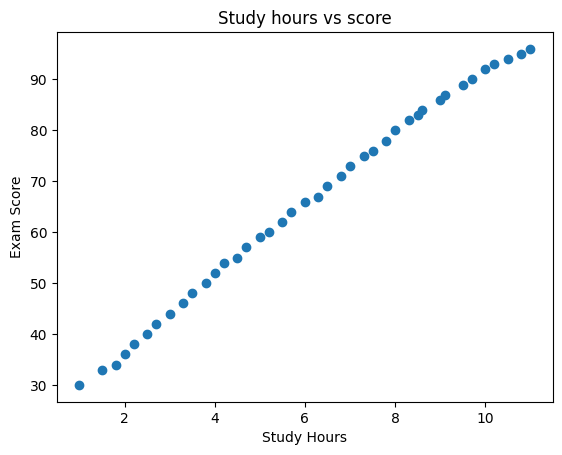

In [27]:
plt.scatter(df["StudyHours"],df["Score"])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study hours vs score")
plt.show()

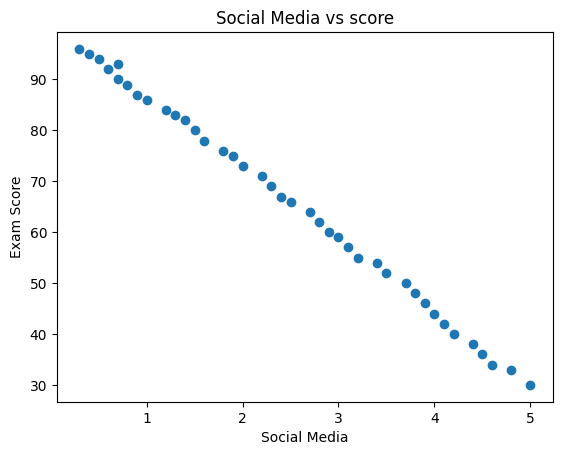

In [28]:
plt.scatter(df["SocialMedia"],df["Score"])
plt.xlabel("Social Media")
plt.ylabel("Exam Score")
plt.title("Social Media vs score")
plt.show()

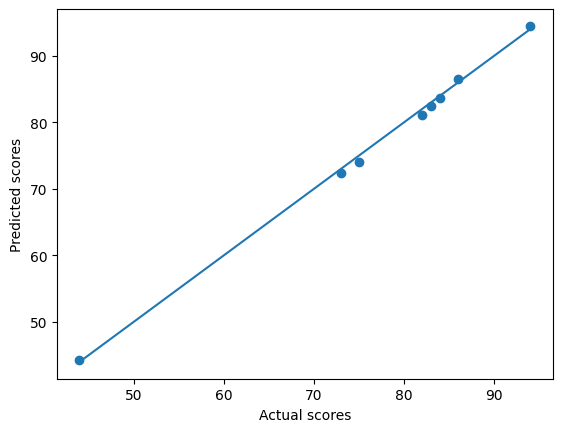

In [29]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual scores")
plt.ylabel("Predicted scores")

plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()])
plt.show()

In [33]:
sample=pd.DataFrame([[8,1]],columns=['StudyHours','SocialMedia'])
prediction=model.predict(sample)
print("Predicted Score for 8 hr study and 1 hr social media:",prediction)

Predicted Score for 8 hr study and 1 hr social media: [84.58551589]
